# Stats 102B Homework 3

## **Author:** Bosen Yang
**Code is modified based on `BCE_SGD.ipynb` from Week 5**

# Part (a): Hyperparameter Tuning

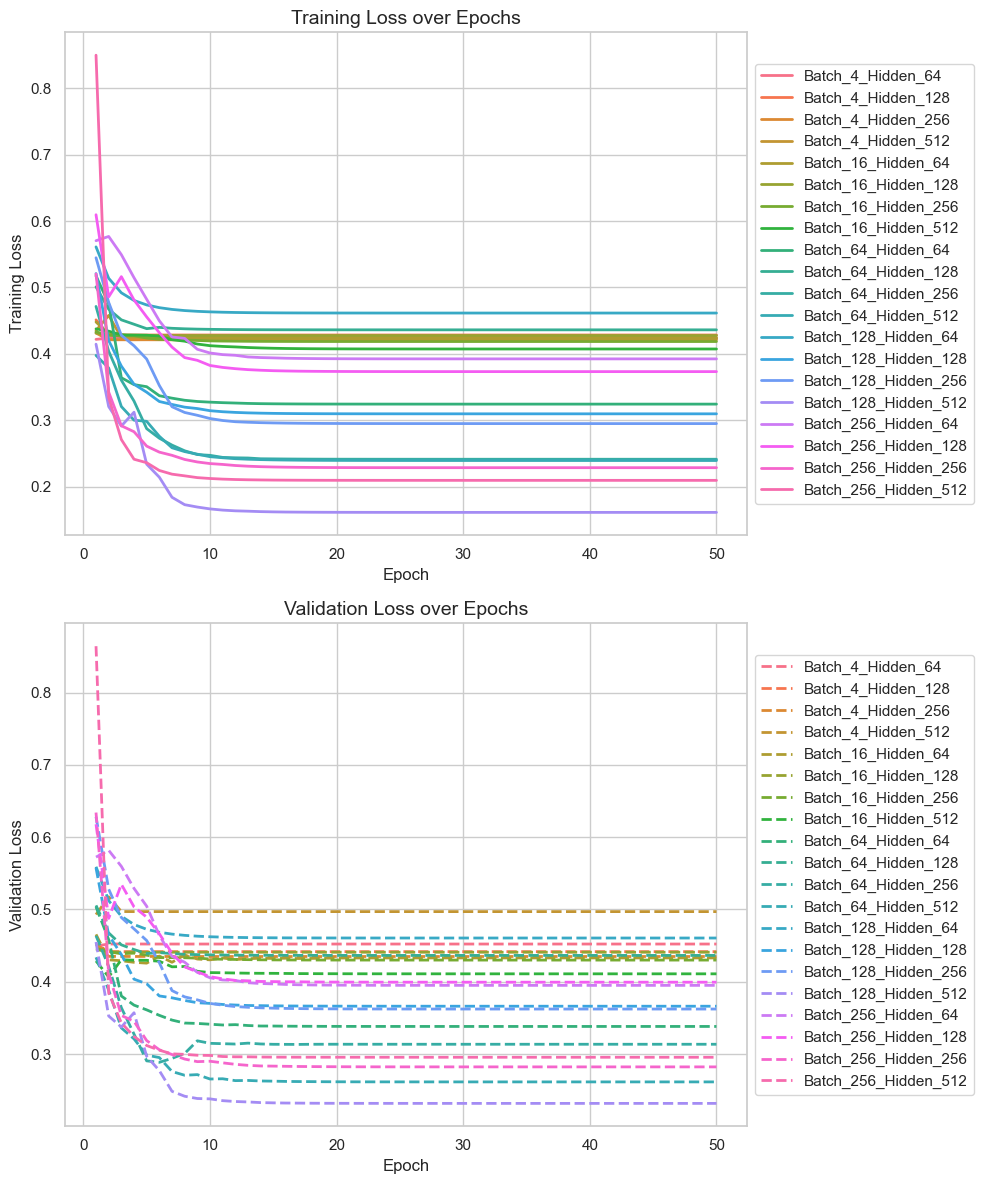

In [80]:
loss_plot()  ## Loss Plot Part a)

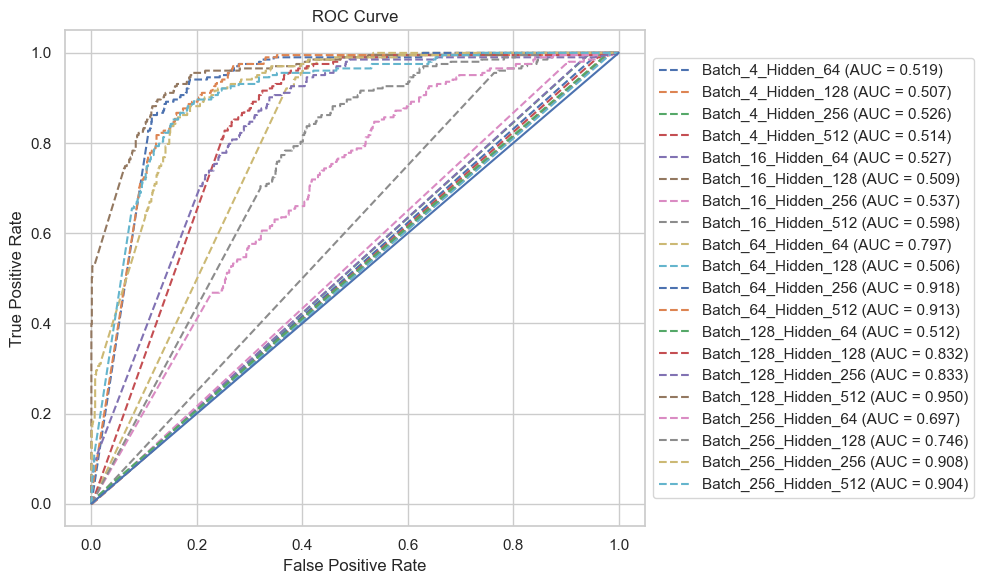

In [81]:
ROC_plot()  ## ROC Plot for Part a)

## Observations
In general, a small initial step size such as `step_size = 0.05` tends to produce better model coefficients. A small batch size (s = 4) usually produces a low AUC while a moderate-to-large batch size tends to produce a high AUC. The AUC also improves as number of layers increases. The loss over epoch plots show very similar patterns between the training and validation dataset, but they are not the exact same. Overall, medium-to-low batch sizes (e.g. 16, 64) tend to give higher losses in both training and validation dataset. 

# Part (b): AMSGrad-Adam

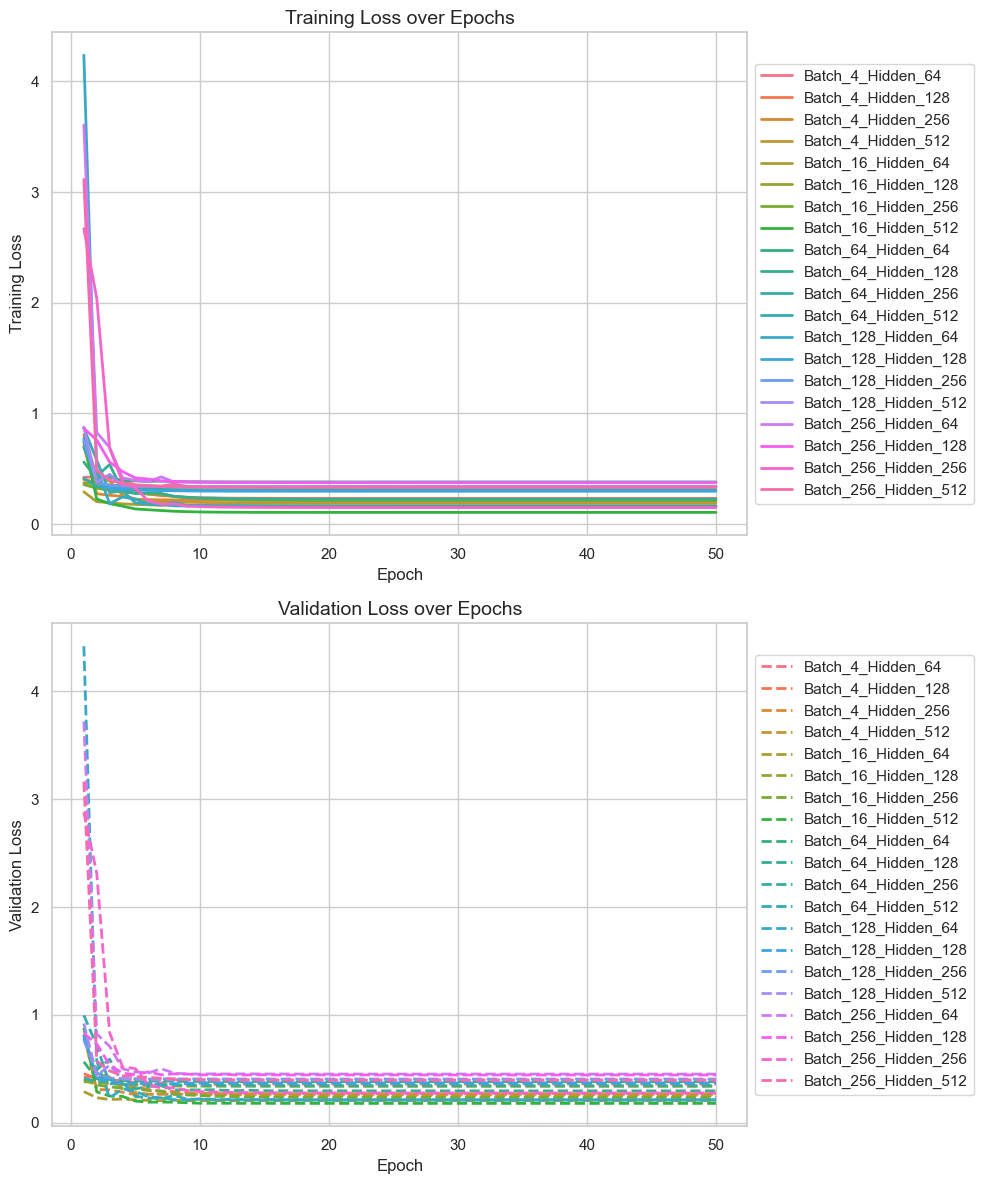

In [93]:
loss_plot()  ## Loss Plot Part b)

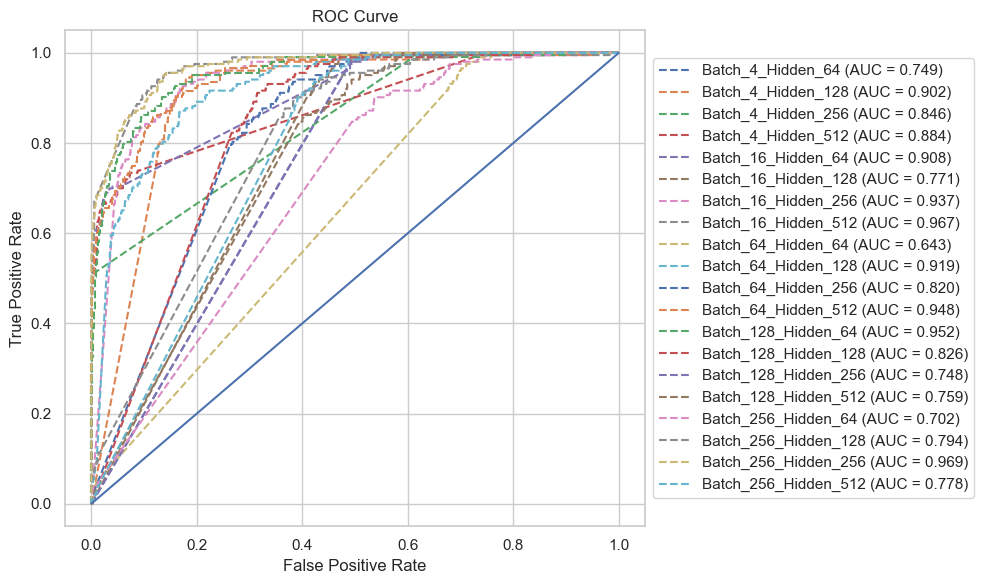

In [94]:
ROC_plot()  ## ROC Plot for Part b)

## Observations
An obvious difference from part a) Convergence Plot is AMSGrad-Adam convergences much faster (taking fewer epochs). In addition, AMSGrad-Adam has much lower best validation loss. Lastly, AMSGrad-Adam has a better separations of batch size and dimension (two obvious tight clusters). In the ROC plot, most combinations of batch size and dimension give a much higher AUC than part a), indicating a huge increase in accuracy. In general, higher hidden layer dimension gives higher AUC.

# Part (c): Scaling the Predictors

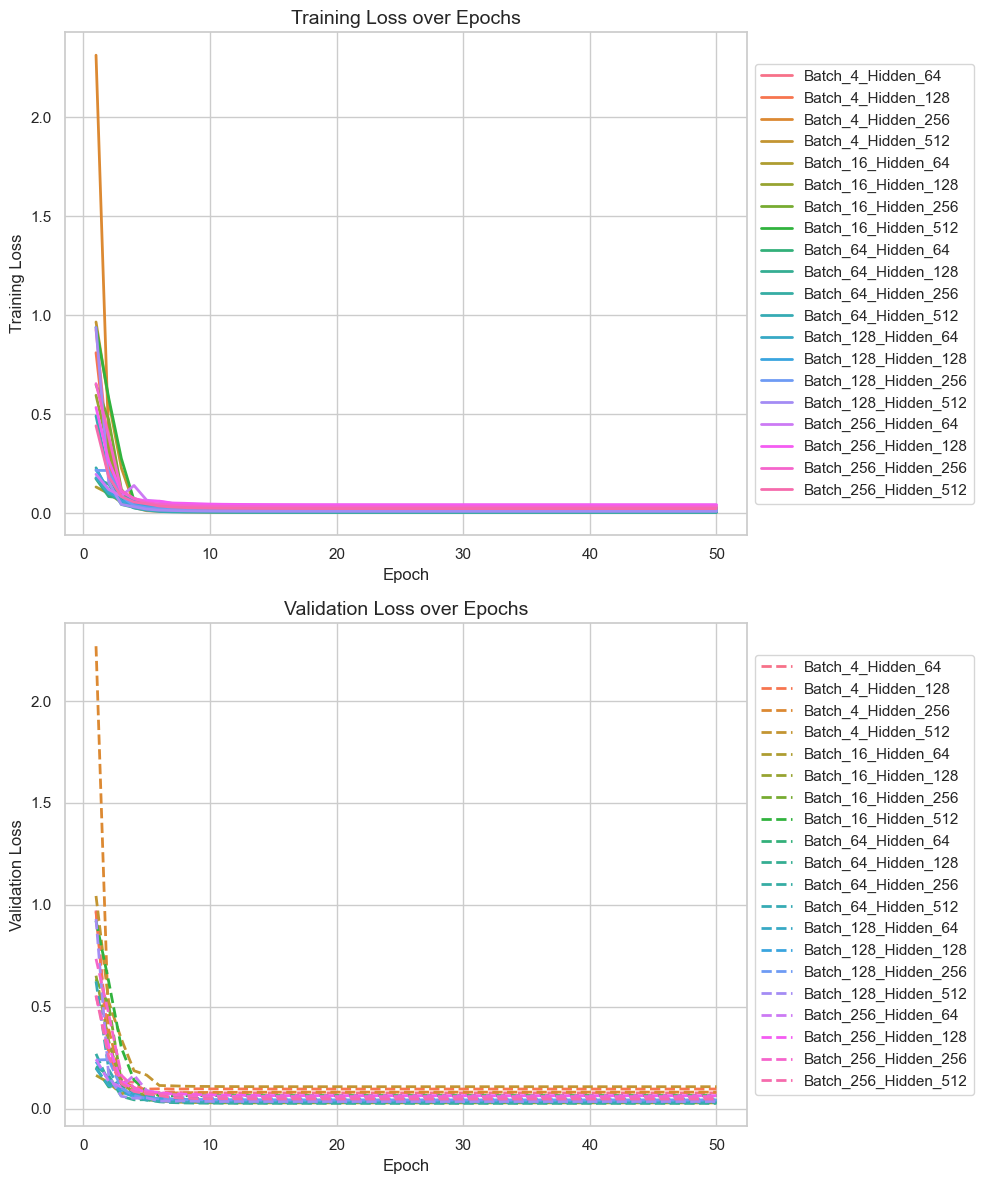

In [44]:
loss_plot()  ## Loss Plot Part c)

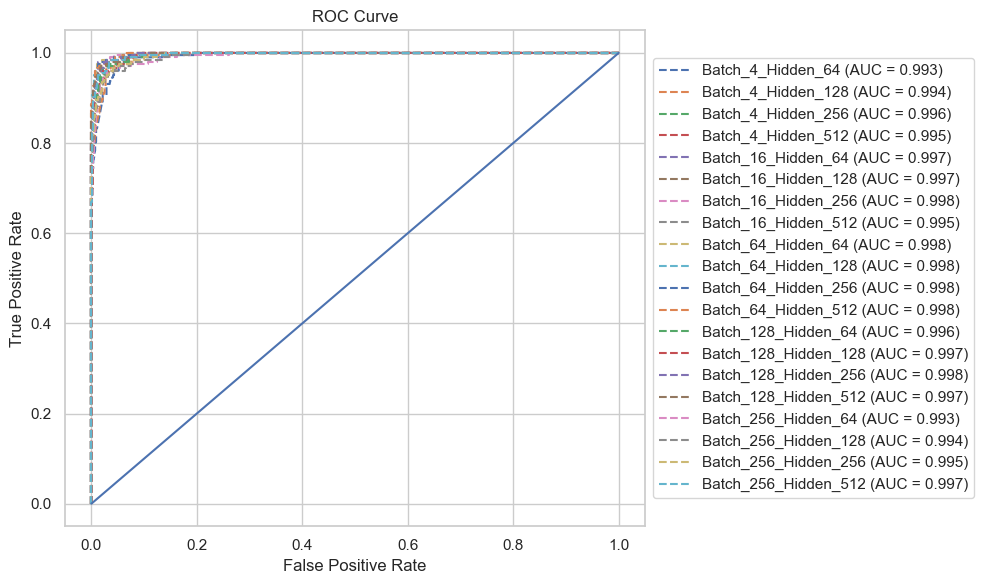

In [54]:
ROC_plot()  ## ROC Plot for Part c)

## Observations:
The convergence rate and accuracy increases dramatically from part a) and part b) after standardization. For all combinations of batch size and dimension, they convergence in 5 epochs and all have AUC > 0.990, indicating a close to excellent accuracy regardless of batch size and dimension. The validation loss curves varies a little more than the training loss, but still much better than part a) and part b)


# Appendix (CODE)

In [75]:
#### --- IMPORTS --- ####
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [76]:
#### --- PARAMETERS --- ####

# Set plotting style to resemble ggplot2
sns.set_theme(style="whitegrid")

# Parameters to simulate binary classification dataset with label noise
seed_parameter = 123
n = 3958           # sample size
p = 166            # number of covariates
corr_factor = 0.5  # correlation factor between predictors
flip_factor = 0.15 # label noise factor

# set hyperparameters for MLP training
epochs = 50                 # epochs
batch_sizes = [4, 16, 64, 128, 256]           # mini-batch size (try: 4, 16, 64, 128, 256)
hidden_sizes = [64, 128, 256, 512] # hidden layer dimension (try: 64, 128, 256, 512)
base_step_size = 0.05        # initial value of step size
decay_rate = 0.7            # decreases step size on a fixed schedule

In [77]:
#### --- READ DATASET --- ####
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")
val = pd.read_csv("val_data.csv")

## Data Processing
y_train = train["target"].values.reshape(-1, 1)
X_train = train.drop(columns=["target"]).values

y_test = test["target"].values.reshape(-1, 1)
X_test = test.drop(columns=["target"]).values

y_val = val["target"].values.reshape(-1, 1)
X_val = val.drop(columns=["target"]).values

In [78]:
#### --- HELPER FUNCTIONS --- ####
def sigmoid(x):
    # np.clip prevents overflow in exp
    x_clipped = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x_clipped))

def relu(x):
    return np.maximum(0, x)

def bce_loss(y_true, y_pred):
    eps = 1e-8
    n_obs = len(y_true)
    return -np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps)) / n_obs

# Xavier initialization function
def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, size=(in_dim, out_dim))

# He initialization function
def he_init(in_dim, out_dim):
    stddev = np.sqrt(2 / in_dim)
    return np.random.normal(0, stddev, size=(in_dim, out_dim))

def mlp_predict_proba(X, params):
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']
    out = X @ W1 + b1
    out = relu(out)
    out = out @ W2 + b2
    return sigmoid(out).ravel()

# Training (PART a)

In [79]:
#### --- Training (MLP) --- ####
# Store results
results = {}

# Initialize variables to track best model
best_model = None
best_val_loss = float('inf')

### THIS PART OF THE CODE CONTAINS THE CORE OF SGD FOR THE MLP
# Training loop

for batch_size in batch_sizes:
    for hidden_size in hidden_sizes:

        # Initialize weights
        W1 = he_init(p, hidden_size)
        b1 = np.zeros((1, hidden_size))
        W2 = xavier_init(hidden_size, 1)
        b2 = np.zeros((1, 1))

        train_loss_history = []
        val_loss_history = []

        n_train = X_train.shape[0]

        for epoch in range(epochs):
            # Learning rate schedule (epoch is 0-indexed in python, so we just use epoch)
            lr = base_step_size * (decay_rate ** epoch)

            # Shuffle training data
            idx = np.random.permutation(n_train)
            X_train_shuffled = X_train[idx]
            y_train_shuffled = y_train[idx]

            for i in range(0, n_train, batch_size):
                batch_end = min(i + batch_size, n_train)
                X_batch = X_train_shuffled[i:batch_end]
                y_batch = y_train_shuffled[i:batch_end]

                current_batch_size = X_batch.shape[0]

                # Forward pass
                # Python broadcasting handles the bias addition automatically
                A = X_batch @ W1 + b1
                H = relu(A)
                Z = H @ W2 + b2
                y_hat = sigmoid(Z)

                # Backward pass
                dZ = y_hat - y_batch
                dW2 = (H.T @ dZ) / current_batch_size
                db2 = np.mean(dZ, axis=0, keepdims=True)

                dH = dZ @ W2.T
                dA = dH * (A > 0)  # ReLU derivative
                dW1 = (X_batch.T @ dA) / current_batch_size
                db1 = np.mean(dA, axis=0, keepdims=True)

                # Update weights
                W1 -= lr * dW1
                b1 -= lr * db1
                W2 -= lr * dW2
                b2 -= lr * db2

            # Compute and track loss
            A_train = relu(X_train @ W1 + b1)
            y_train_pred = sigmoid(A_train @ W2 + b2)
            train_loss = bce_loss(y_train, y_train_pred)

            A_val = relu(X_val @ W1 + b1)
            y_val_pred = sigmoid(A_val @ W2 + b2)
            val_loss = bce_loss(y_val, y_val_pred)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)

        # Save training history
        key = f"Batch_{batch_size}_Hidden_{hidden_size}"
        results[key] = {'train': train_loss_history, 
                        'val': val_loss_history,
                        'model': {'W1': W1.copy(), 'b1': b1.copy(), 'W2': W2.copy(), 'b2': b2.copy()}
                       }

        # Update best model
        if min(val_loss_history) < best_val_loss:
            best_val_loss = min(val_loss_history)
            best_model = {'W1': W1.copy(), 'b1': b1.copy(),
                          'W2': W2.copy(), 'b2': b2.copy(),
                          'val_loss': best_val_loss}

# Loss Over Epoch Plot Function

In [42]:
#### --- PLOTTING --- ####
def loss_plot():
    # Prepare data for plotting
    plot_data = []
    for key, values in results.items():
        for epoch in range(epochs):
            plot_data.append({
                'Epoch': epoch + 1,
                'Loss': values['train'][epoch],
                'LossType': 'Training',
                'Model': key
            })
            plot_data.append({
                'Epoch': epoch + 1,
                'Loss': values['val'][epoch],
                'LossType': 'Validation',
                'Model': key
            })
    
    loss_df = pd.DataFrame(plot_data)
    
    # Create the plots
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))
    
    # === Training Loss Plot ===
    train_df = loss_df[loss_df['LossType'] == 'Training']
    sns.lineplot(data=train_df, x='Epoch', y='Loss', hue='Model',
                 linewidth=2, ax=axes[0])
    axes[0].set_title("Training Loss over Epochs", fontsize=14)
    axes[0].set_ylabel("Training Loss")
    axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    # === Validation Loss Plot ===
    val_df = loss_df[loss_df['LossType'] == 'Validation']
    sns.lineplot(data=val_df, x='Epoch', y='Loss', hue='Model',
                 linewidth=2, linestyle='--', ax=axes[1])
    axes[1].set_title("Validation Loss over Epochs", fontsize=14)
    axes[1].set_ylabel("Validation Loss")
    axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

# ROC Plot Function

In [49]:
## ROC Plots with AUC
def ROC_plot():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for key, values in results.items():
        y_score = mlp_predict_proba(X_test, values['model'])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{key} (AUC = {roc_auc:.3f})", linestyle='--')
    
    plt.plot([0, 1], [0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.savefig("ROC_1.png", dpi=300, bbox_inches='tight')
    plt.show()

# Training (PART b)

In [92]:
#### --- Training (AMSGrad Adam MLP) --- ####

### Parameters
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

# Store results
results = {}

# Initialize variables to track best model
best_model = None
best_val_loss = float('inf')

### THIS PART OF THE CODE CONTAINS THE CORE OF SGD FOR THE MLP
# Training loop

for batch_size in batch_sizes:
    for hidden_size in hidden_sizes:

        # Initialize weights
        W1 = he_init(p, hidden_size)
        b1 = np.zeros((1, hidden_size))
        W2 = xavier_init(hidden_size, 1)
        b2 = np.zeros((1, 1))

        # First and second moments
        mW1, zW1, zmaxW1 = [np.zeros_like(W1) for _ in range(3)]
        mb1, zb1, zmaxb1 = [np.zeros_like(b1) for _ in range(3)]
        mW2, zW2, zmaxW2 = [np.zeros_like(W2) for _ in range(3)]
        mb2, zb2, zmaxb2 = [np.zeros_like(b2) for _ in range(3)]

        train_loss_history = []
        val_loss_history = []

        n_train = X_train.shape[0]

        t = 0
        for epoch in range(epochs):
            
            # Learning rate schedule (epoch is 0-indexed in python, so we just use epoch)
            lr = base_step_size * (decay_rate ** epoch)

            # Shuffle training data
            idx = np.random.permutation(n_train)
            X_train_shuffled = X_train[idx]
            y_train_shuffled = y_train[idx]

            for i in range(0, n_train, batch_size):
                t += 1
                batch_end = min(i + batch_size, n_train)
                X_batch = X_train_shuffled[i:batch_end]
                y_batch = y_train_shuffled[i:batch_end]

                current_batch_size = X_batch.shape[0]

                # Forward pass
                # Python broadcasting handles the bias addition automatically
                A = X_batch @ W1 + b1
                H = relu(A)
                Z = H @ W2 + b2
                y_hat = sigmoid(Z)

                # Backward pass
                dZ = y_hat - y_batch
                dW2 = (H.T @ dZ) / current_batch_size
                db2 = np.mean(dZ, axis=0, keepdims=True)

                dH = dZ @ W2.T
                dA = dH * (A > 0)  # ReLU derivative
                dW1 = (X_batch.T @ dA) / current_batch_size
                db1 = np.mean(dA, axis=0, keepdims=True)

                # Update weights

                ## -- W1 -- ##
                mW1 = beta1 * mW1 + (1 - beta1) * dW1
                zW1 = beta2 * zW1 + (1 - beta2) * (dW1 ** 2)
                zmaxW1 = np.maximum(zmaxW1, zW1)
                mW1_hat = mW1 / (1 - beta1 ** t)
                zmaxW1_corr = zmaxW1 / (1 - beta2 ** t)
                W1 -= lr * mW1_hat / (np.sqrt(zmaxW1_corr) + eps)

                ## -- b1 -- ##
                mb1 = beta1 * mb1 + (1 - beta1) * db1
                zb1 = beta2 * zb1 + (1 - beta2) * (db1 ** 2)
                zmaxb1 = np.maximum(zmaxb1, zb1)
                mb1_hat = mb1 / (1 - beta1 ** t)
                zmaxb1_corr = zmaxb1 / (1 - beta2 ** t)
                b1 -= lr * mb1_hat / (np.sqrt(zmaxb1_corr) + eps)

                ## --- W2 -- ##
                mW2 = beta1 * mW2 + (1 - beta1) * dW2
                zW2 = beta2 * zW2 + (1 - beta2) * (dW2 ** 2)
                zmaxW2 = np.maximum(zmaxW2, zW2)
                mW2_hat = mW2 / (1 - beta1 ** t)
                zmaxW2_corr = zmaxW2 / (1 - beta2 ** t)
                W2 -= lr * mW2_hat / (np.sqrt(zmaxW2_corr) + eps)
                
                ## -- b2 -- ##
                mb2 = beta1 * mb2 + (1 - beta1) * db2
                zb2 = beta2 * zb2 + (1 - beta2) * (db2 ** 2)
                zmaxb2 = np.maximum(zmaxb2, zb2)
                mb2_hat = mb2 / (1 - beta1 ** t)
                zmaxb2_corr = zmaxb2 / (1 - beta2 ** t)
                b2 -= lr * mb2_hat / (np.sqrt(zmaxb2_corr) + eps)

            # Compute and track loss
            A_train = relu(X_train @ W1 + b1)
            y_train_pred = sigmoid(A_train @ W2 + b2)
            train_loss = bce_loss(y_train, y_train_pred)

            A_val = relu(X_val @ W1 + b1)
            y_val_pred = sigmoid(A_val @ W2 + b2)
            val_loss = bce_loss(y_val, y_val_pred)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)

        # Save training history
        key = f"Batch_{batch_size}_Hidden_{hidden_size}"
        results[key] = {'train': train_loss_history, 
                        'val': val_loss_history,
                        'model': {'W1': W1.copy(), 'b1': b1.copy(), 'W2': W2.copy(), 'b2': b2.copy()}
                       }

        # Update best model
        if min(val_loss_history) < best_val_loss:
            best_val_loss = min(val_loss_history)
            best_model = {'W1': W1.copy(), 'b1': b1.copy(),
                          'W2': W2.copy(), 'b2': b2.copy(),
                          'val_loss': best_val_loss}

# Standardize the Dataset (PART c)

In [22]:
## Compute mean and sd
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-8

## Standardization
X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# Training (PART c)

In [23]:
#### --- Training (AMSGrad Adam MLP) --- ####

### Parameters
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

# Store results
results = {}

# Initialize variables to track best model
best_model = None
best_val_loss = float('inf')

### THIS PART OF THE CODE CONTAINS THE CORE OF SGD FOR THE MLP
# Training loop

for batch_size in batch_sizes:
    for hidden_size in hidden_sizes:

        # Initialize weights
        W1 = he_init(p, hidden_size)
        b1 = np.zeros((1, hidden_size))
        W2 = xavier_init(hidden_size, 1)
        b2 = np.zeros((1, 1))

        # First and second moments
        mW1, zW1, zmaxW1 = [np.zeros_like(W1) for _ in range(3)]
        mb1, zb1, zmaxb1 = [np.zeros_like(b1) for _ in range(3)]
        mW2, zW2, zmaxW2 = [np.zeros_like(W2) for _ in range(3)]
        mb2, zb2, zmaxb2 = [np.zeros_like(b2) for _ in range(3)]

        train_loss_history = []
        val_loss_history = []

        n_train = X_train.shape[0]

        t = 0
        for epoch in range(epochs):
            
            # Learning rate schedule (epoch is 0-indexed in python, so we just use epoch)
            lr = base_step_size * (decay_rate ** epoch)

            # Shuffle training data
            idx = np.random.permutation(n_train)
            X_train_shuffled = X_train[idx]
            y_train_shuffled = y_train[idx]

            for i in range(0, n_train, batch_size):
                t += 1
                batch_end = min(i + batch_size, n_train)
                X_batch = X_train_shuffled[i:batch_end]
                y_batch = y_train_shuffled[i:batch_end]

                current_batch_size = X_batch.shape[0]

                # Forward pass
                # Python broadcasting handles the bias addition automatically
                A = X_batch @ W1 + b1
                H = relu(A)
                Z = H @ W2 + b2
                y_hat = sigmoid(Z)

                # Backward pass
                dZ = y_hat - y_batch
                dW2 = (H.T @ dZ) / current_batch_size
                db2 = np.mean(dZ, axis=0, keepdims=True)

                dH = dZ @ W2.T
                dA = dH * (A > 0)  # ReLU derivative
                dW1 = (X_batch.T @ dA) / current_batch_size
                db1 = np.mean(dA, axis=0, keepdims=True)

                # Update weights

                ## -- W1 -- ##
                mW1 = beta1 * mW1 + (1 - beta1) * dW1
                zW1 = beta2 * zW1 + (1 - beta2) * (dW1 ** 2)
                zmaxW1 = np.maximum(zmaxW1, zW1)
                mW1_hat = mW1 / (1 - beta1 ** t)
                zmaxW1_corr = zmaxW1 / (1 - beta2 ** t)
                W1 -= lr * mW1_hat / (np.sqrt(zmaxW1_corr) + eps)

                ## -- b1 -- ##
                mb1 = beta1 * mb1 + (1 - beta1) * db1
                zb1 = beta2 * zb1 + (1 - beta2) * (db1 ** 2)
                zmaxb1 = np.maximum(zmaxb1, zb1)
                mb1_hat = mb1 / (1 - beta1 ** t)
                zmaxb1_corr = zmaxb1 / (1 - beta2 ** t)
                b1 -= lr * mb1_hat / (np.sqrt(zmaxb1_corr) + eps)

                ## --- W2 -- ##
                mW2 = beta1 * mW2 + (1 - beta1) * dW2
                zW2 = beta2 * zW2 + (1 - beta2) * (dW2 ** 2)
                zmaxW2 = np.maximum(zmaxW2, zW2)
                mW2_hat = mW2 / (1 - beta1 ** t)
                zmaxW2_corr = zmaxW2 / (1 - beta2 ** t)
                W2 -= lr * mW2_hat / (np.sqrt(zmaxW2_corr) + eps)
                
                ## -- b2 -- ##
                mb2 = beta1 * mb2 + (1 - beta1) * db2
                zb2 = beta2 * zb2 + (1 - beta2) * (db2 ** 2)
                zmaxb2 = np.maximum(zmaxb2, zb2)
                mb2_hat = mb2 / (1 - beta1 ** t)
                zmaxb2_corr = zmaxb2 / (1 - beta2 ** t)
                b2 -= lr * mb2_hat / (np.sqrt(zmaxb2_corr) + eps)

            # Compute and track loss
            A_train = relu(X_train @ W1 + b1)
            y_train_pred = sigmoid(A_train @ W2 + b2)
            train_loss = bce_loss(y_train, y_train_pred)

            A_val = relu(X_val @ W1 + b1)
            y_val_pred = sigmoid(A_val @ W2 + b2)
            val_loss = bce_loss(y_val, y_val_pred)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)

        # Save training history
        key = f"Batch_{batch_size}_Hidden_{hidden_size}"
        results[key] = {'train': train_loss_history, 
                        'val': val_loss_history,
                        'model': {'W1': W1.copy(), 'b1': b1.copy(), 'W2': W2.copy(), 'b2': b2.copy()}
                       }

        # Update best model
        if min(val_loss_history) < best_val_loss:
            best_val_loss = min(val_loss_history)
            best_model = {'W1': W1.copy(), 'b1': b1.copy(),
                          'W2': W2.copy(), 'b2': b2.copy(),
                          'val_loss': best_val_loss}